In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import pbn_37k
from pbn_37k.ask import sigAssistant

import pandas as pd
from tqdm import tqdm
tqdm.pandas()

from dotenv import load_dotenv
load_dotenv()

brain = sigAssistant(pathCache=".cache/", llm_highend="gpt-4o",  llm_fast="gpt-4o-mini")

In [25]:
with open("data/cities/prompt/prompt.md", "r") as f:
    prompt_template = f.read()
with open("data/cities/activities.md", "r") as f:
    prompt_activity = f.read()
with open("data/cities/portfolio.md", "r") as f:
    prompt_portfolio = f.read()
with open("data/cities/prompt/cities.md", "r") as f:
    cities = [x.strip("*").strip() for x in f.read().split("\n") ]
cn = ["gotham", "baraddur", "kingslanding", "coruscant", "wakanda", "shire", "capitol"]

In [26]:
HEADER = """---
layout: default
title: TITLE
parent: PARENT
has_children: true
nav_order: NAVORDER
---\n\n"""

In [75]:
CITIES = {}
VISIONS = []
ACTIVITIES = []

for i in range(len(cities)):
    desc = cities[i]
    q = prompt_template.replace("$CITYNAME$", desc)
    urban_report = brain.ask(q)
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    

    analysis = brain.analyseText( txt=urban_report,
            TypeOfItem = "Vision",
            Source="maptivity.online",
            Place=cn[i].title(),
            MIN=15,
            Reviewed=True,
            MODEL="gpt-4o-mini")
        
    CITIES[cn[i]] = {"report": urban_report}
    VISIONS.append(urban_report)

    report = HEADER.replace("TITLE", cn[i].title()).replace("NAVORDER", str(i+3)).replace("\nparent: PARENT","") + "![](places/"+cn[i]+".png)\n\n" + urban_report
    report = report.replace("## **Overview & Sustainability Profile**","## Overview & Sustainability Profile")
    SCORE = "\n\n### ISO37101 mapping for '"+analysis.Source_Title.unique()[0]+"'\n\n#### Scores\n\n" + analysis[["Score","Purpose","Issue","Justification"]].to_markdown(index=False)+"\n\n"
    report = report + SCORE
    
    with open(f"docs/{cn[i]}_report.md", "w") as f:
        f.write(report)

--- gpt-4o-mini:	 2025-10-23 12:00:24
Already done
--- gpt-4o-mini:	 2025-10-23 12:00:24
Already done
--- gpt-4o-mini:	 2025-10-23 12:00:24
Already done
--- gpt-4o-mini:	 2025-10-23 12:00:24
Already done
--- gpt-4o-mini:	 2025-10-23 12:00:24
Already done
--- gpt-4o-mini:	 2025-10-23 12:00:24
Already done
--- gpt-4o-mini:	 2025-10-23 12:00:24
Already done


In [88]:
for i in range(len(cities)):
    desc = CITIES[cn[i]]["report"]
    q = prompt_portfolio.replace("DESCRIPTION", desc)
    urban_report = brain.ask(q)

    
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    urban_report = "![](images/"+cn[i]+"_review.png)\n\n" + urban_report
    report = HEADER.replace("TITLE", cn[i].title()+"'s portfolio").replace("NAVORDER", "1").replace("PARENT",cn[i].title()) + urban_report
    CITIES[cn[i]]["portfolio"] = {"portfolio": report}
    with open(f"docs/{cn[i]}_portfolio.md", "w") as f:
        f.write(report)

    for k in range(7):
        q = prompt_activity.replace("$$DESC$$", desc).replace("$$ACT$$", urban_report)
        q = q.replace("$$NN$$ ", str(k+1))
        activity_report = brain.ask(q)
        ACTIVITIES.append(activity_report)
        CITIES[cn[i]]["portfolio"][f"activity_{k+1}"] = activity_report
        analysis = brain.analyseText( txt=activity_report,
                        TypeOfItem = "Activity",
                        Source="maptivity.online",
                        Place=cn[i].title(),
                        MIN=7,
                        Reviewed=False,
                        MODEL="gpt-4o-mini")

        reportB = activity_report


        SCORE = "\n\n### ISO37101 mapping for '"+analysis.Source_Title.unique()[0]+"'\n\n#### Scores\n\n" + analysis[["Score","Purpose","Issue","Justification"]].to_markdown(index=False)+"\n\n"

        reportB = reportB.replace("## **CONTEXTUAL FOUNDATION**",SCORE + "## **CONTEXTUAL FOUNDATION**")
        shorttitle = reportB.split("###")[1].split("\n")[1].replace("**","").split(":")[0].strip().replace('"','').replace("/","-")
        print(cn[i], k+1, shorttitle)
        reportB = HEADER.replace("TITLE", shorttitle).replace("NAVORDER", str(k+2)).replace("PARENT",cn[i].title()) + reportB
        reportB = reportB.replace("has_children: true _n","")


        with open(f"docs/{cn[i]}_activity_{k+1}.md", "w") as f:
            f.write(reportB)

--- gpt-4o-mini:	 2025-10-23 12:05:47
--- gpt-4o-mini:	 2025-10-23 12:05:47
Already done
gotham 1 Gotham Watch
--- gpt-4o-mini:	 2025-10-23 12:05:47
Already done
gotham 2 Gotham Greenway Revitalization Initiative
--- gpt-4o-mini:	 2025-10-23 12:05:47
Already done
gotham 3 Gotham Artisan Alley
--- gpt-4o-mini:	 2025-10-23 12:05:47
Already done
gotham 4 Sky Gardens Initiative
--- gpt-4o-mini:	 2025-10-23 12:05:48
Already done
gotham 5 Gotham Unity Fest
--- gpt-4o-mini:	 2025-10-23 12:05:48
Already done
gotham 6 Gotham Resilience Haven
--- gpt-4o-mini:	 2025-10-23 12:05:48
Already done
gotham 7 Gotham Connect
--- gpt-4o-mini:	 2025-10-23 12:05:48
--- gpt-4o-mini:	 2025-10-23 12:05:48
Already done
baraddur 1 Restoring the Ashen Oasis
--- gpt-4o-mini:	 2025-10-23 12:05:48
Already done
baraddur 2 Mordor Marketplace Initiative
--- gpt-4o-mini:	 2025-10-23 12:05:48
Already done
baraddur 3 Barad-dûr Resilience Collective
--- gpt-4o-mini:	 2025-10-23 12:05:48
Already done
baraddur 4 The Echoes o

# Reviews

In [93]:
import pbn_37k.img as iImg
from pbn_37k.reportmgr import createExcel

df = brain.getMemory()
df = df[df.Source.isin(ACTIVITIES+VISIONS)]
print(len(df))
df.head(2)
df.Scale = df.Scale.str.strip().str.capitalize()
df.Scale = df.Scale.apply(lambda x: x.replace("Neighborhood","Neighbourhood").replace("City-wide","Neighbourhood"))
df.Scale = df.Scale.apply(lambda x: x.replace("District","Neighbourhood").replace("City","Neighbourhood"))
df.Scale = df.Scale.apply(lambda x: x.replace("Hyperlocal","Building"))
df.Scale.unique()

589


array(['Neighbourhood', 'Building'], dtype=object)

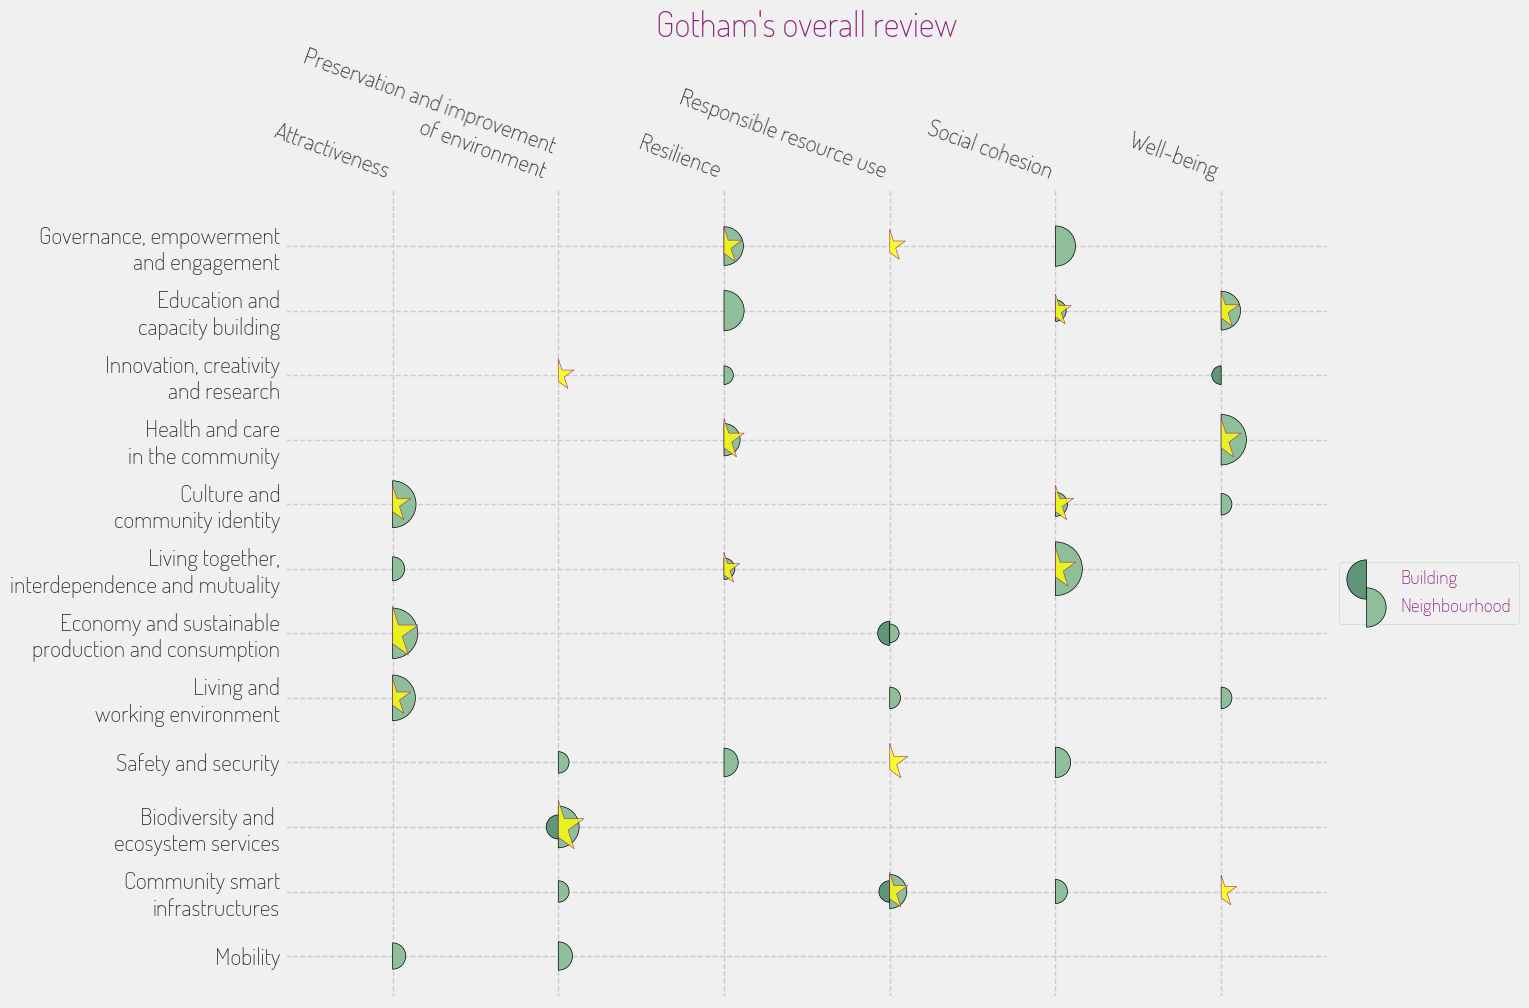

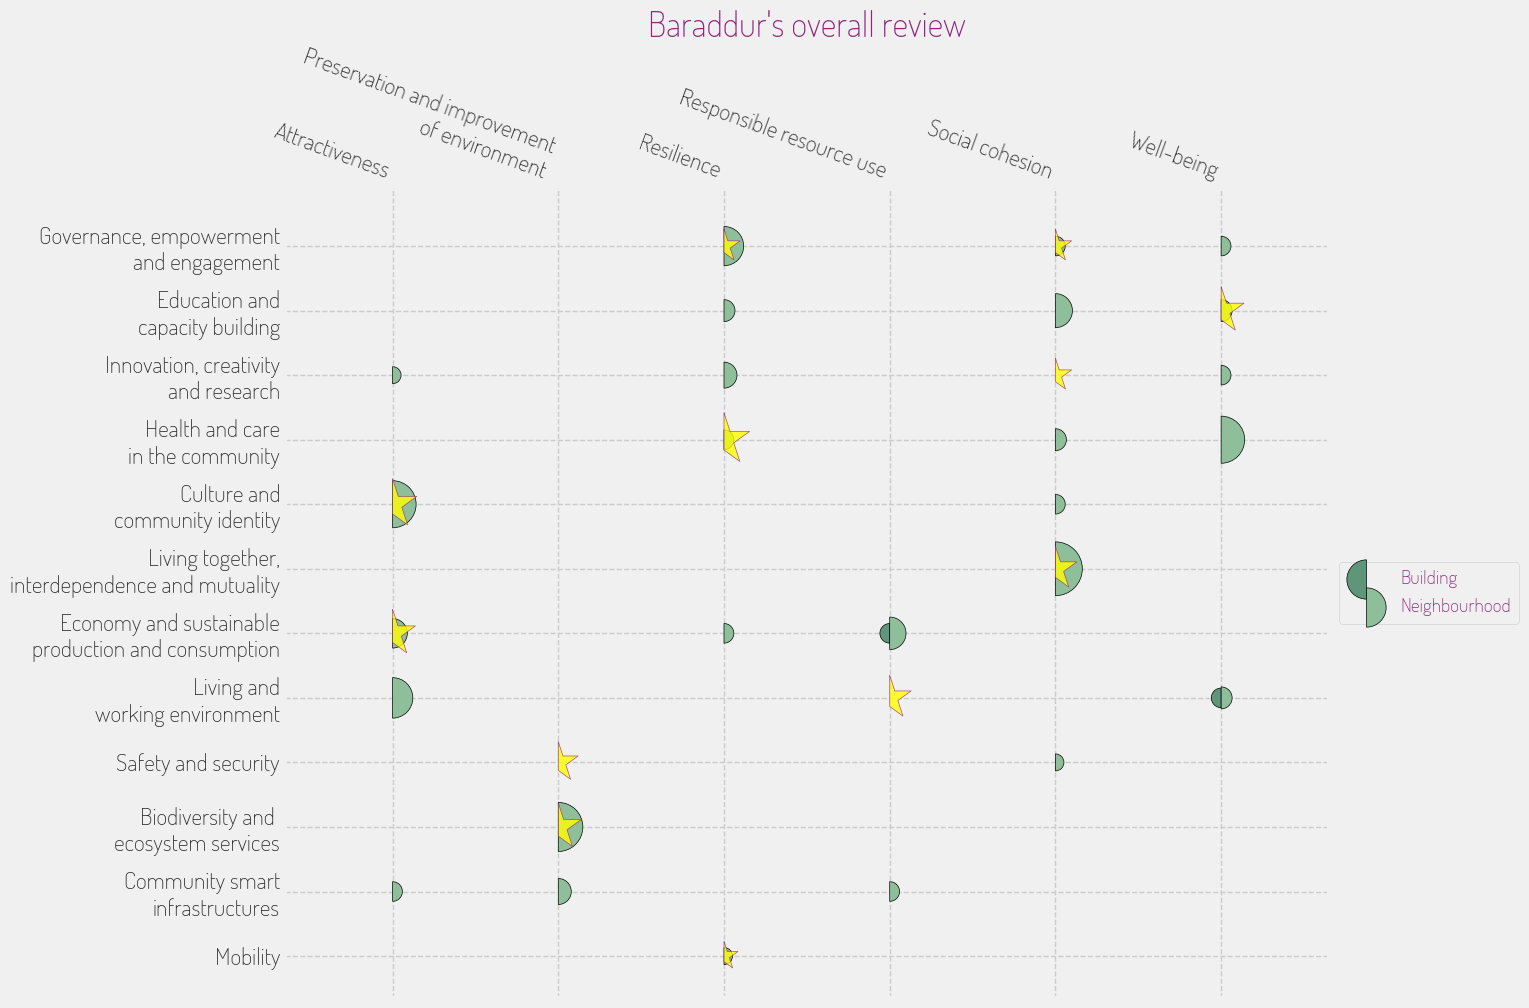

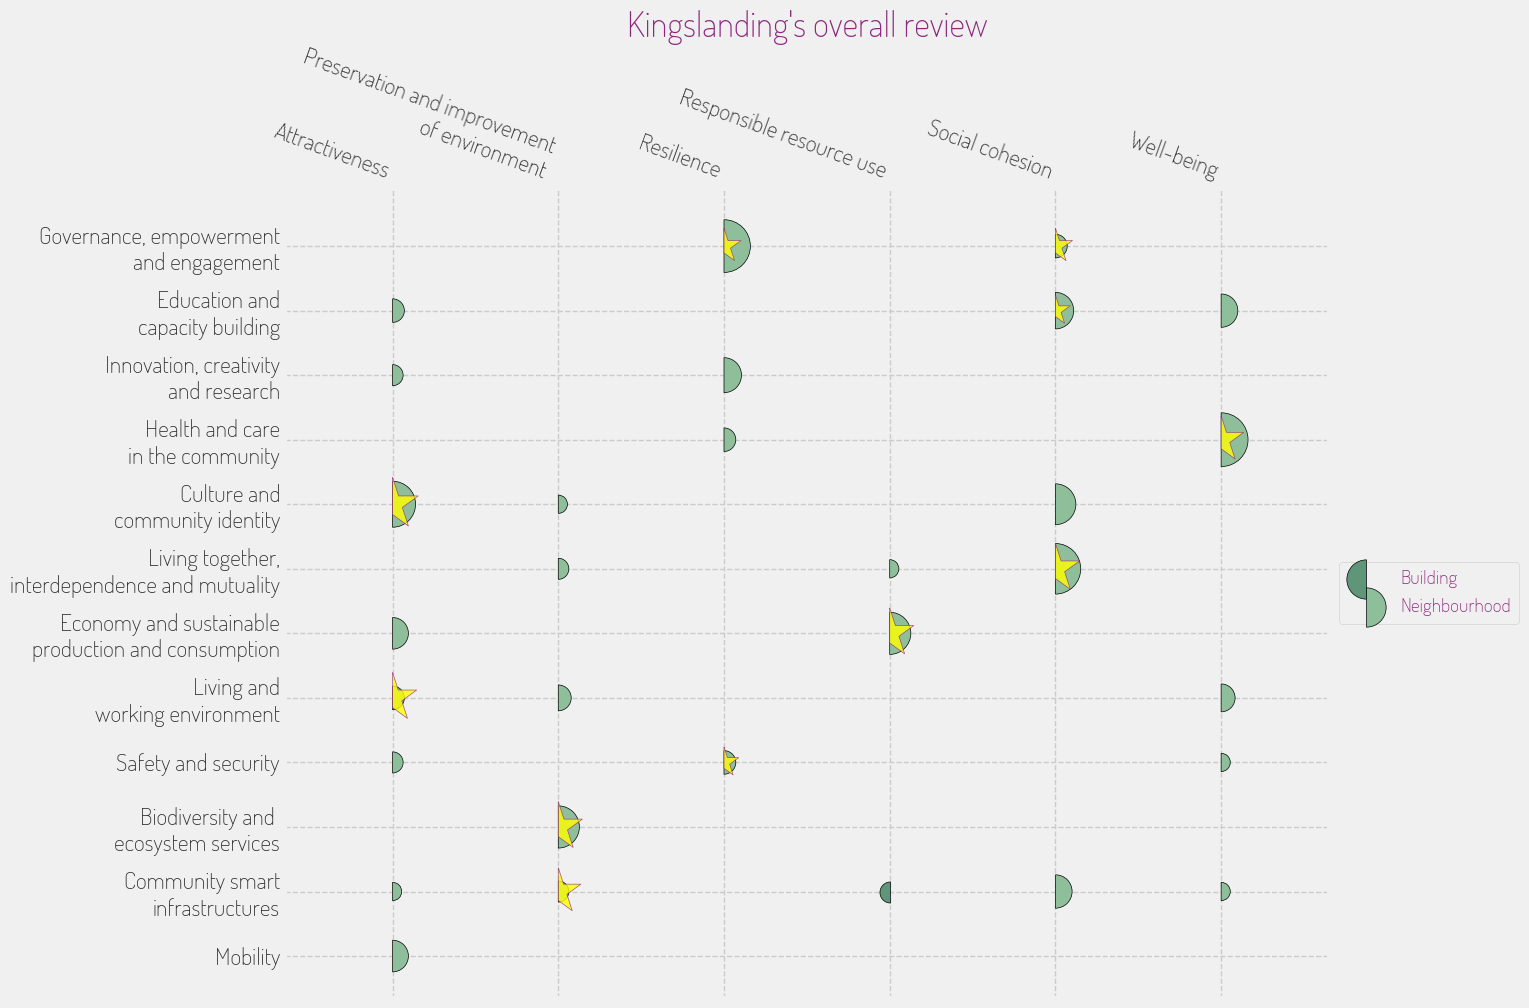

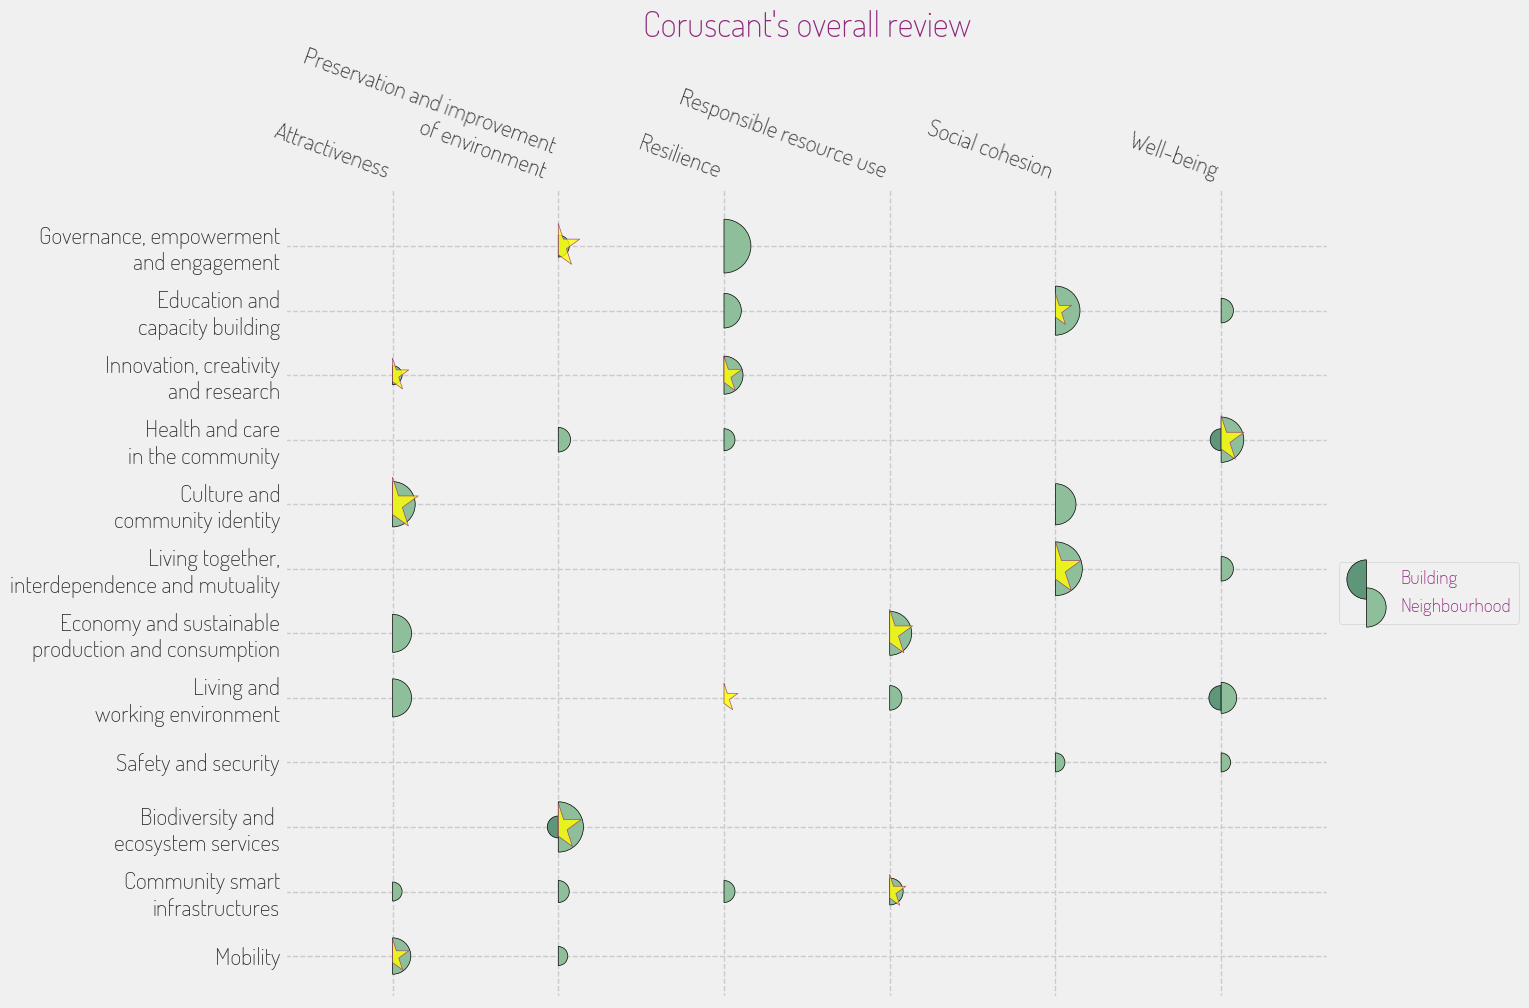

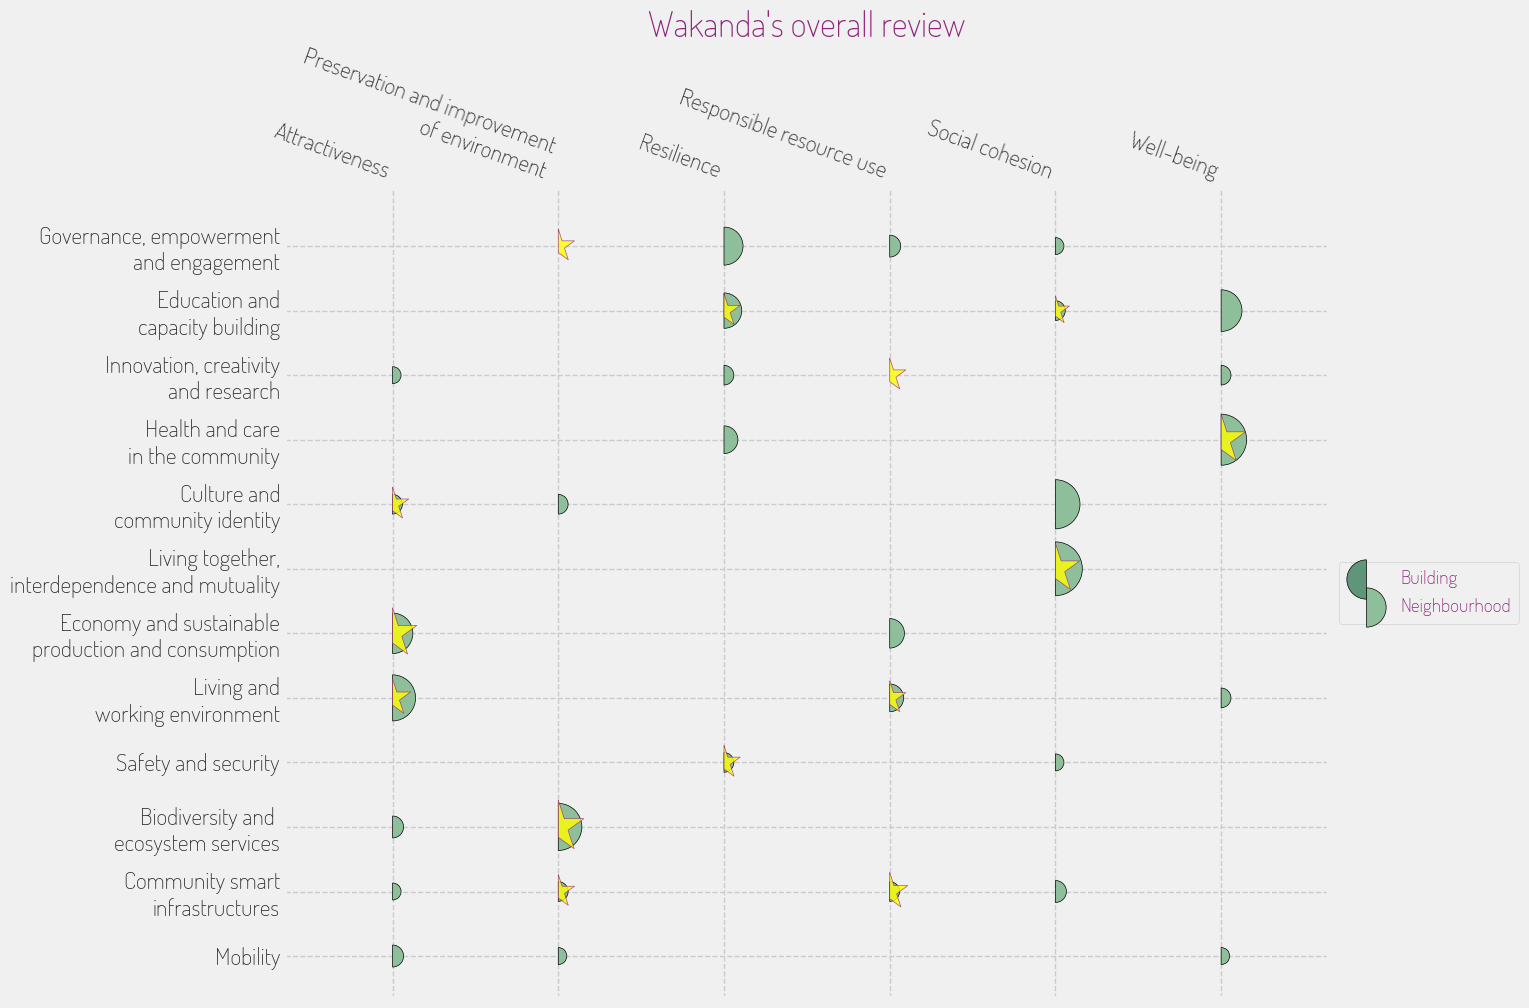

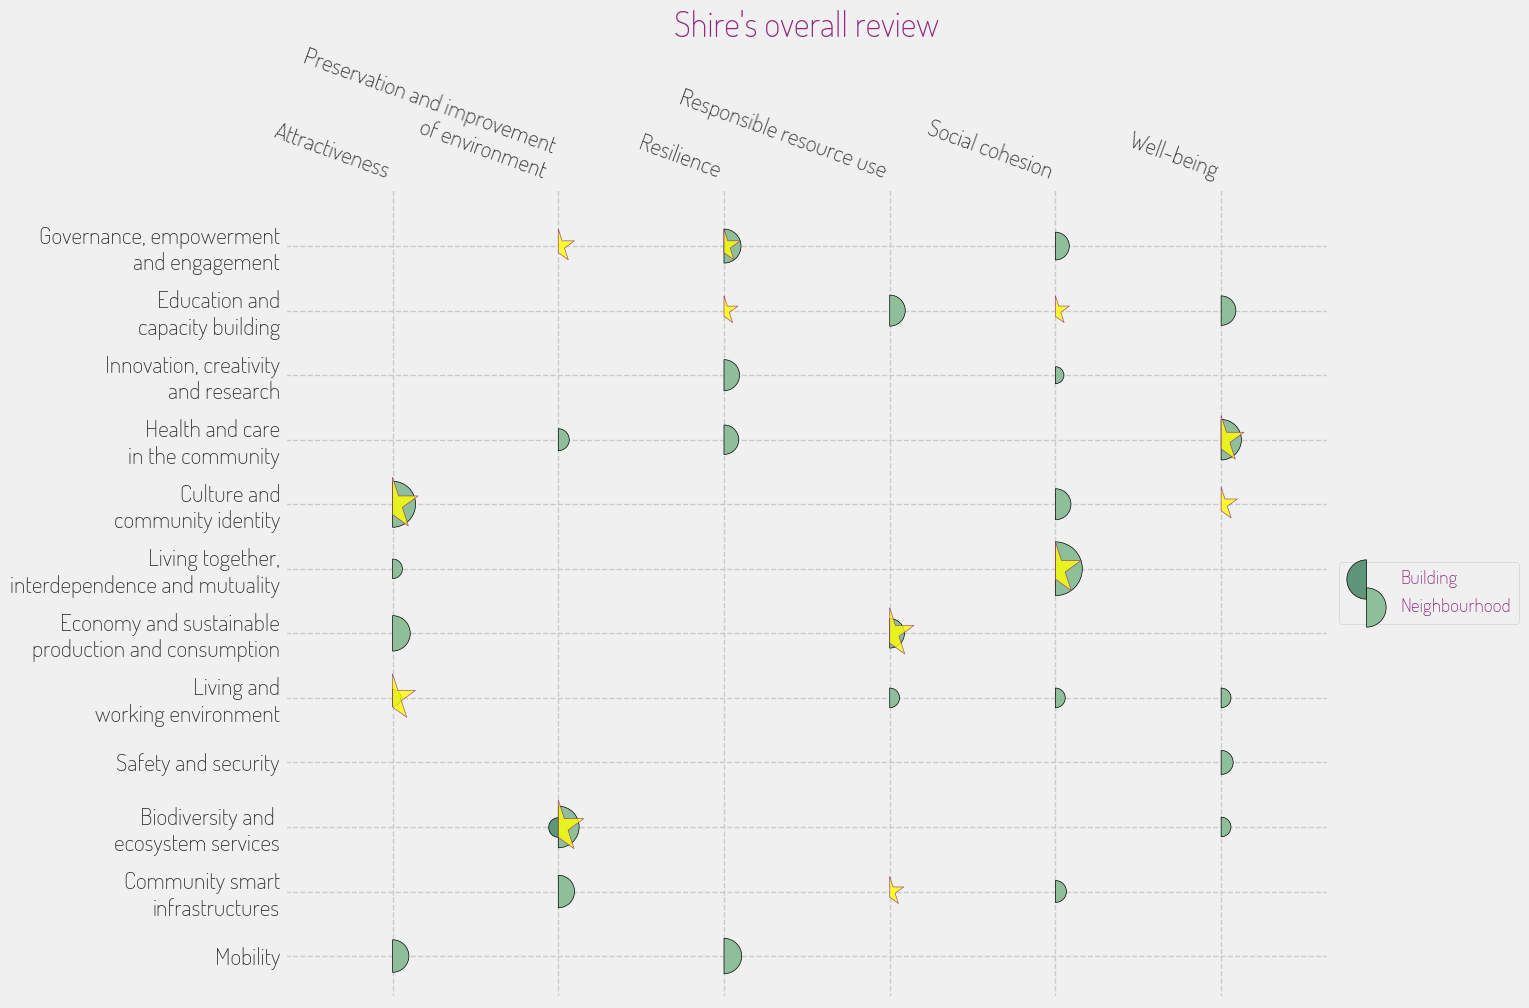

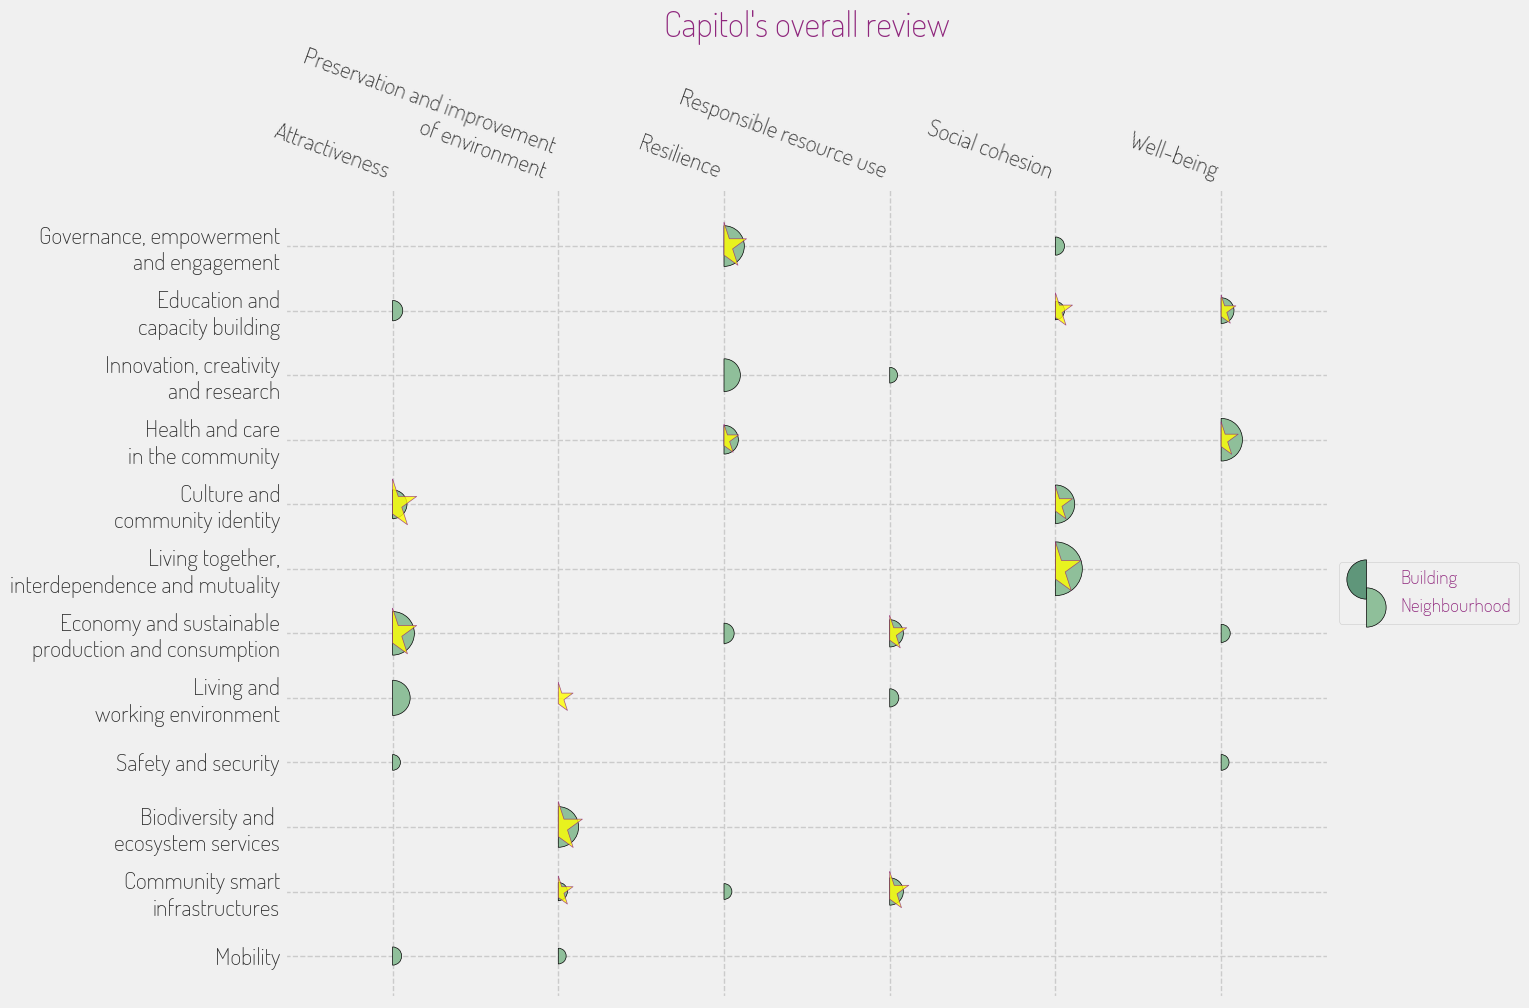

In [94]:
for place in df.Place.unique():
    D = df[df.Place == place]
    dfRef = D[D.Type == "Vision"]
    dfUC  = D[D.Type == "Activity"]
    plt, ax = iImg.createImg(dfUC, dfRef, title=place+"'s overall review")
    plt.savefig("docs/images/"+place.lower()+"_review.png",  bbox_inches="tight")

# Definitions

"# B.12 Mobility\n- defined as the provision of safe, comfortable, comprehensive, dependable, efficient, accessible, affordable and appropriate mobility services for different age and special needs groups, particularly for persons with disabilities. This includes maintaining a reliable transport system, improving connectivity, encouraging non-motorized traffic like walking and cycling, and facilitating the transport of goods. Key aspects involve evaluating how investments in improved mobility contribute to greater economic interaction, open new contacts, diversify local trade, and enhance the overall attractiveness of the community. It also considers steps taken to reduce pollution and greenhouse gas emissions from the community's mobility services, and how mobility conditions impact quality of life. "

In [109]:
with open(pbn_37k.dbkg.path_to_defs, "r") as f:
    defs = f.read().split("\n#")

DEFS = "## Definitions\n\nTo help with the Placemaking Maptivity, it helps to understand some key definitions that represent the game area.\n\n" 

P = [x[6:].strip() for  x in defs[2:8]]
I = [x[6:].strip() for  x in defs[9:-1]]+[defs[-1].split("\n\n")[0]]
DEFS += "\n\n### Issues\n\n"
for i in I:
    a, b  = i.split("\n",1)
    x = brain.ask("Define the following ISO37101 Issue: " + a + "\n\nIt is described as : " + b +"\n\nWrite a paragraph that a teenager would understand, but also in a business appropriate manner for stakeholder engagement. Start your answer with '**"+a+"** is defined as '..." )
    DEFS += " * "+x +"\n"
DEFS += "\n\n### Purposes\n\n"
for i in P:
    a, b  = i.split("\n",1)
    x = brain.ask("Define the following ISO37101 Purpose: " + a + "\n\nIt is described as : " + b +"\n\nWrite a paragraph that a teenager would understand, but also in a business appropriate manner for stakeholder engagement. Start your answer with '**"+a+"** is defined as '..." )
    DEFS += " * "+x +"\n"

--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59
--- gpt-4o-mini:	 2025-10-23 13:06:59


In [111]:
HH = """---
layout: default
title: The PlaceMaking Maptivity
nav_order: 1
---

"""

In [116]:
example = """

## An example

Following a game session, people will have place activitie and visions for their neighbourhoods. Here is an example of a report that could be generated automatically to summarize the outcomes of the session.

![](images/gotham_review.png)

On this map, **stars** represent the Vision of the Place, and Circles represent Activities proposed to improve the sustainability of the neighbourhood.

A star aligned with a circle means that the activity contributes to achieving the vision.  When there's a circle but no star, it means the activity is beneficial but not directly linked to a specific vision.
Conversely, a star without a circle indicates a vision that currently lacks a supporting activity.


"""

In [117]:
with open("data/description.md", "r") as f:
    t = f.read()
with open("docs/index.md", "w") as f:
    f.write(HH + t + example + DEFS)
